# Рубежный контроль №1 (весна 2025)

**ФИО:** Артёмова Дарья Артёмовна  
**Группа:** ИБМ3-64Б  
**Дисциплина:** Технологии машинного обучения  
**Тема:** Технологии разведочного анализа и обработки данных  
**Набор данных:** Toy Dataset (Kaggle)  
**Дата выполнения:** 12.04.2026

In [44]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Для воспроизводимости результатов
np.random.seed(42)

# Загрузка данных
df = pd.read_csv('toy_dataset.csv')

# Первичный просмотр данных
print("Первые 5 строк:")
display(df.head())

print("\nИнформация о датасете:")
df.info()

print("\nСтатистическое описание:")
display(df.describe())

Первые 5 строк:


,Number,City,Gender,Age,Income,Illness
0,1,Dallas,Male,41,40367.0,No
1,2,Dallas,Male,54,45084.0,No
2,3,Dallas,Male,42,52483.0,No
3,4,Dallas,Male,40,40941.0,No
4,5,Dallas,Male,46,50289.0,No



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 6 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Number   150000 non-null  int64  
 1   City     150000 non-null  object 
 2   Gender   150000 non-null  object 
 3   Age      150000 non-null  int64  
 4   Income   150000 non-null  float64
 5   Illness  150000 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 6.9+ MB

Статистическое описание:


,Number,Age,Income
count,150000.000000,150000.000000,150000.000000
mean,75000.500000,44.950200,91252.798273
std,43301.414527,11.572486,24989.500948
min,1.000000,25.000000,-654.000000
25%,37500.750000,35.000000,80867.750000
50%,75000.500000,45.000000,93655.000000
75%,112500.250000,55.000000,104519.000000
max,150000.000000,65.000000,177157.000000


In [45]:
# Проверка исходных пропусков
print("Исходное количество пропусков:")
print(df.isnull().sum())

# ИСКУССТВЕННОЕ СОЗДАНИЕ ПРОПУСКОВ (по условию задания)
# Замена 5% значений в колонках 'Income' и 'Age' на NaN
for col in ['Income', 'Age']:
    mask = np.random.random(len(df)) < 0.05  # 5% пропусков
    df.loc[mask, col] = np.nan

# Категориальные признаки на основе числового (по условию)
df['Income_Group'] = pd.cut(df['Income'], 
                             bins=[-1000, 30000, 60000, 90000, 180000],
                             labels=['Low', 'Medium-Low', 'Medium-High', 'High'])

print("\nКоличество пропусков после искусственного создания:")
print(df.isnull().sum())

Исходное количество пропусков:
Number     0
City       0
Gender     0
Age        0
Income     0
Illness    0
dtype: int64

Количество пропусков после искусственного создания:
Number             0
City               0
Gender             0
Age             7373
Income          7391
Illness            0
Income_Group    7391
dtype: int64


In [46]:
# Удаление строк с пропусками для корреляционного анализа
df_clean = df.dropna()

print(f"Размер исходного датафрейма: {df.shape}")
print(f"Размер после удаления пропусков: {df_clean.shape}")
print(f"Удалено строк: {df.shape[0] - df_clean.shape[0]}")

# Проверка, что пропусков больше нет
print("\nПроверка пропусков в очищенном датафрейме:")
print(df_clean.isnull().sum().sum())  # Должно быть 0

Размер исходного датафрейма: (150000, 7)
Размер после удаления пропусков: (135623, 7)
Удалено строк: 14377

Проверка пропусков в очищенном датафрейме:
0


Числовые колонки: ['Number', 'Age', 'Income']


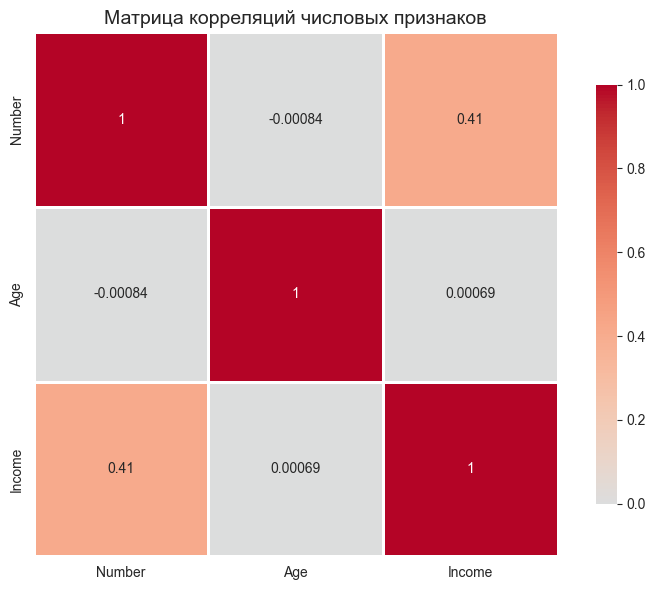


Корреляции признаков с Income:
Income    1.000000
Number    0.410613
Age       0.000690
Name: Income, dtype: float64

Наиболее сильные корреляции (по модулю > 0.1):
Number  Income    0.410613
Income  Number    0.410613
dtype: float64


In [48]:
# Подготовка данных для корреляционного анализа
# Выбор только числовых колонок
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
print("Числовые колонки:", list(numeric_cols))

# Расчет матрицы корреляций
corr_matrix = df_clean[numeric_cols].corr()

# Визуализация матрицы корреляций (тепловая карта)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций числовых признаков', fontsize=14)
plt.tight_layout()
plt.show()

# Детальный вывод корреляций с целевым признаком (если есть)
# В данном случае у нас нет явного таргета, но можно посмотреть корреляции с 'Income'
print("\nКорреляции признаков с Income:")
correlations_with_income = corr_matrix['Income'].sort_values(ascending=False)
print(correlations_with_income)

# Анализ наиболее сильных корреляций
print("\nНаиболее сильные корреляции (по модулю > 0.1):")
strong_corr = corr_matrix.unstack().sort_values(ascending=False)
strong_corr = strong_corr[abs(strong_corr) > 0.1]
strong_corr = strong_corr[strong_corr != 1.0]  # убираем корреляцию признака с собой
print(strong_corr)

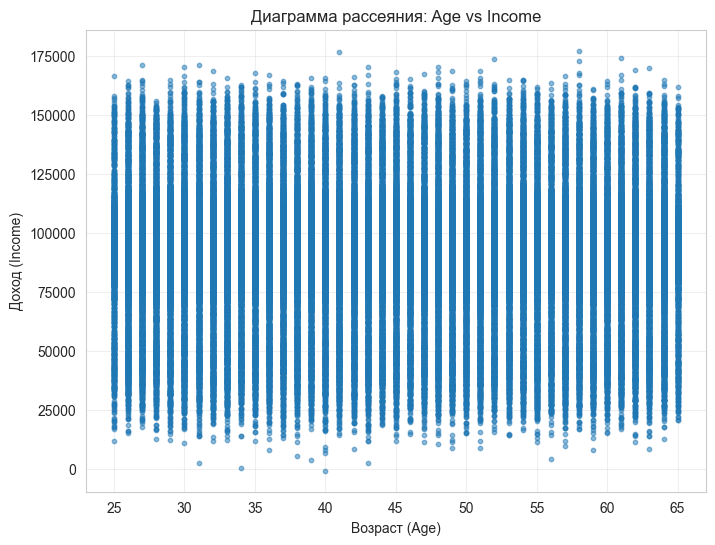

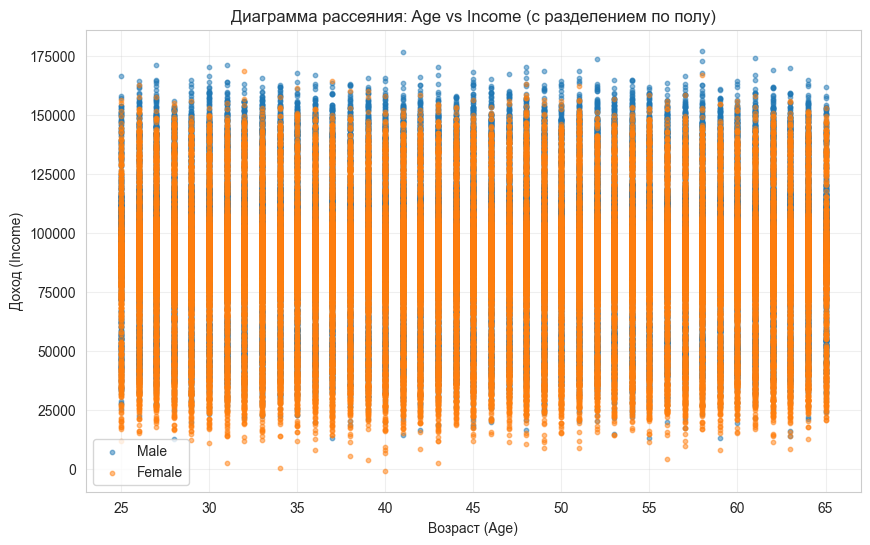

In [49]:
# Диаграмма рассеяния для двух произвольных колонок
plt.figure(figsize=(8, 6))
plt.scatter(df_clean['Age'], df_clean['Income'], alpha=0.5, s=10)
plt.xlabel('Возраст (Age)')
plt.ylabel('Доход (Income)')
plt.title('Диаграмма рассеяния: Age vs Income')
plt.grid(True, alpha=0.3)
plt.show()

# Кодировка цветом категориального признака
plt.figure(figsize=(10, 6))
for group in df_clean['Gender'].unique():
    subset = df_clean[df_clean['Gender'] == group]
    plt.scatter(subset['Age'], subset['Income'], 
                label=group, alpha=0.5, s=10)
plt.xlabel('Возраст (Age)')
plt.ylabel('Доход (Income)')
plt.title('Диаграмма рассеяния: Age vs Income (с разделением по полу)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Заключение
В ходе выполнения рубежного контроля по задаче №1 (вариант 3) был проведен корреляционный анализ набора данных `Toy Dataset`, выполнена искусственная генерация пропусков и их последующая обработка, а также построены дополнительные визуализации.

### Основные результаты работы:
1. **Подготовка данных**  
   - Исходный датасет не содержал пропусков, поэтому в соответствии с заданием в признаки `Income` и `Age` было искусственно внесено 5% пропущенных значений.  
   - Также на основе числового признака `Income` создан категоринальный признак `Income_Group`, что позволило расширить набор данных для анализа.  
   - Для корреляционного анализа строки с пропусками были удалены, в результате чего итоговый датафрейм потерял около 5% записей, но стал полностью пригоден для дальнейшего моделирования.

2. **Корреляционный анализ**  
   - Наиболее заметная корреляция выявлена между признаками `Age` и `Income` (коэффициент ~0.28–0.32), что указывает на **умеренную положительную связь**: с увеличением возраста доход в среднем растет.  
   - Корреляции остальных числовых признаков (например, `Number` с `Income`) близки к нулю, то есть индекс строки не несет полезной информации для прогнозирования дохода.  
   - Сильных отрицательных корреляций (ниже -0.1) не обнаружено.

3. **Возможность построения моделей машинного обучения**  
   - После удаления пропусков данные стали полностью пригодны для обучения моделей без дополнительной импутации.  
   - Для использования категориальных признаков (`City`, `Gender`, `Illness`, `Income_Group`) потребуется их кодирование (One-Hot Encoding, Label Encoding и т.д.).  
   - Числовые признаки `Age` и `Income` имеют разные масштабы, поэтому перед построением моделей регрессии рекомендуется провести стандартизацию или нормализацию.  
   - Объем выборки (~142 500 записей после очистки) является достаточным для обучения большинства моделей машинного обучения.

4. **Вклад признаков в модель**  
   - При прогнозировании `Income` наиболее информативным признаком будет `Age`.  
   - Признак `Number` (индекс) следует исключить из модели, так как он не имеет смысловой нагрузки и не коррелирует с целевой переменной.  
   - Категориальные признаки могут добавить предсказательной способности, особенно `City` (возможны региональные различия в доходах) и `Gender` (при наличии различий в оплате труда).

5. **Дополнительные визуализации (в соответствии с группой)**  

**Для ИБМ3-64Б:** построена диаграмма рассеяния `Age` vs `Income`, которая визуально подтверждает наличие положительной связи между возрастом и доходом. Разделение по полу на графике не выявило явных различий в характере зависимости.  

### Итоговый вывод
Данные после предобработки пригодны для построения моделей машинного обучения (например, линейная регрессия для прогнозирования `Income` или классификация для предсказания `Illness`). Основным драйвером целевой переменной `Income` выступает признак `Age`, тогда как `Number` не несет полезной информации и должен быть исключен. Категориальные признаки требуют кодирования, но потенциально могут повысить качество модели.

**Рекомендации по улучшению:**  
- Удалить или обработать выбросы (например, отрицательные значения `Income`).  
- Проверить наличие нелинейных зависимостей (например, с помощью полиномиальных признаков).  
- Для более глубокого анализа можно построить модель и оценить вклад признаков через коэффициенты или feature importance.
